## Classical Baselines 

Two unsupervised baselines are fitted on the **same normal-only training data**, using mean-pooled sequences as flat feature vectors.

| Baseline | Idea |
|----------|------|
| **Isolation Forest** | Randomly partitions the feature space; anomalies are isolated in fewer splits |
| **Local Outlier Factor** | Flags points whose local density is much lower than their neighbours |


### Dependencies

In [1]:
# Run once to install everything needed
%pip install torch scikit-learn pandas matplotlib numpy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch  : 2.11.0+cpu
Device   : CPU


### Configuration

In [3]:
DATA_PATH = "engineered_network_traffic.csv"   
OUT_DIR   = "outputs"

CFG = dict(
    seq_len       = 30,     # sliding-window length (time steps)
    train_frac    = 0.60,   # fraction used for training (time-ordered)
    hidden_dim    = 64,     # LSTM hidden size
    latent_dim    = 16,     # bottleneck dimension
    num_layers    = 2,      # stacked LSTM layers
    dropout       = 0.2,
    epochs        = 10,
    batch_size    = 128,
    lr            = 1e-3,
    threshold_pct = 99.0,   # percentile for anomaly threshold
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Config loaded. OUT_DIR:", OUT_DIR)

Config loaded. OUT_DIR: outputs


In [4]:
def make_sequences(data, seq_len):
    """Sliding window → (N, seq_len, n_features)."""
    return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len+1)],
                    dtype=np.float32)



# Read data
df_feat = pd.read_csv(DATA_PATH)

# Specify columns for features only.
FEAT_COLS = [c for c in df_feat.columns if c not in ("label", "Label", "Timestamp")]

# Displaying the matrix size
print(f"Feature matrix : {len(df_feat):,} rows × {len(FEAT_COLS)} columns")

# Display statistics (describe) with rounding to 3 decimal places
df_feat[FEAT_COLS].describe().round(3)

Feature matrix : 2,830,743 rows × 22 columns


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packets/s,Bwd Packets/s,Min Packet Length,...,Packet Length Std,Destination Port,Flow Duration_rmean,Flow Duration_rstd,Total Fwd Packets_rmean,Total Fwd Packets_rstd,Total Backward Packets_rmean,Total Backward Packets_rstd,Total Length of Fwd Packets_rmean,Total Length of Fwd Packets_rstd
count,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,...,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.000,2830743.0,2830743.000
mean,0.123,0.000,0.000,0.000,0.000,0.113,0.345,0.021,0.003,0.011,...,0.062,0.123,0.123,0.106,0.000,0.000,0.000,0.000,0.0,0.000
std,0.280,0.003,0.003,0.001,0.003,0.011,0.044,0.083,0.019,0.017,...,0.134,0.279,0.220,0.149,0.001,0.003,0.001,0.003,0.0,0.001
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
25%,0.000,0.000,0.000,0.000,0.000,0.112,0.333,0.000,0.000,0.000,...,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.112,0.333,0.000,0.000,0.001,...,0.005,0.001,0.015,0.015,0.000,0.000,0.000,0.000,0.0,0.000
75%,0.027,0.000,0.000,0.000,0.000,0.112,0.337,0.004,0.004,0.025,...,0.037,0.007,0.116,0.210,0.000,0.000,0.000,0.000,0.0,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,0.995,0.527,0.101,0.316,0.101,0.316,0.1,0.316


In [5]:
# Train / test split (time-ordered, no shuffle) 
X_all = df_feat[FEAT_COLS].values.astype(np.float32)
y_all = df_feat["label"].values
ts_all = df_feat["Timestamp"].values if "Timestamp" in df_feat.columns else None

n_train     = int(len(X_all) * CFG["train_frac"])
X_tr_raw    = X_all[:n_train];  y_tr = y_all[:n_train]
X_te_raw    = X_all[n_train:];  y_te = y_all[n_train:]
X_tr_normal = X_tr_raw[y_tr == 0]   # unsupervised: train on normal only

print(f"Train (normal) : {len(X_tr_normal):,}")
print(f"Test           : {len(X_te_raw):,}  (attacks: {y_te.sum():,})")

# Sliding-window sequences
seq_len   = CFG["seq_len"]
seqs_tr   = make_sequences(X_tr_normal, seq_len)
seqs_te   = make_sequences(X_te_raw,    seq_len)
y_te_seq  = y_te[seq_len-1 : seq_len-1+len(seqs_te)]
ts_te_seq = (ts_all[n_train+seq_len-1 : n_train+seq_len-1+len(seqs_te)]
             if ts_all is not None else None)

print(f"Train sequences : {seqs_tr.shape}  (normal only)")
print(f"Test  sequences : {seqs_te.shape}")


Train (normal) : 1,429,722
Test           : 1,132,298  (attacks: 288,923)
Train sequences : (1429693, 30, 22)  (normal only)
Test  sequences : (1132269, 30, 22)


In [6]:
# Mean-pool each sequence → flat feature vector (N, n_features)
X_tr_flat = seqs_tr.mean(axis=1)
X_te_flat = seqs_te.mean(axis=1)

contamination = float(y_te_seq.mean())   
print(f"Contamination estimate: {contamination:.3f}")

# Isolation Forest
print("\nFitting Isolation Forest …")
iso_clf = IsolationForest(n_estimators=200, contamination=contamination,
                          random_state=42, n_jobs=-1)
iso_clf.fit(X_tr_flat)
if_scores = -iso_clf.decision_function(X_te_flat)   

# LOF
print("Fitting Local Outlier Factor …")
lof_clf = LocalOutlierFactor(n_neighbors=20, novelty=True, n_jobs=-1)
lof_clf.fit(X_tr_flat)
lof_scores = -lof_clf.decision_function(X_te_flat)

print("Done.")

Contamination estimate: 0.255

Fitting Isolation Forest …
Fitting Local Outlier Factor …


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

Done.


## Evaluation & Visualisation 

Metrics used:
- **ROC-AUC** — area under the ROC curve (threshold-free)
- **AUPRC** — area under the Precision-Recall curve (better for imbalanced data)
- **Classification report** — precision / recall / F1 at the chosen threshold


In [9]:
def norm01(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-12)

def evaluate(y_true, scores, name):
    threshold = np.percentile(scores, CFG["threshold_pct"])
    y_pred    = (scores >= threshold).astype(int)
    ap  = average_precision_score(y_true, scores)
    try:
        auc = roc_auc_score(y_true, scores)
    except ValueError:
        auc = float("nan")
    print(f"\n{'─'*52}")
    print(f" {name}")
    print(f"{'─'*52}")
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Attack"],
                                zero_division=0))
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  AUPRC   : {ap:.4f}")
    return {"name": name, "auc": auc, "ap": ap,
            "scores": scores, "threshold": threshold}


if_n   = norm01(if_scores)
lof_n  = norm01(lof_scores)

results = [
    evaluate(y_te_seq, if_n,   "Isolation Forest"),
    evaluate(y_te_seq, lof_n,  "Local Outlier Factor"),
]


────────────────────────────────────────────────────
 Isolation Forest
────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.74      0.99      0.85    843346
      Attack       0.00      0.00      0.00    288923

    accuracy                           0.73   1132269
   macro avg       0.37      0.49      0.42   1132269
weighted avg       0.55      0.73      0.63   1132269

  ROC-AUC : 0.8071
  AUPRC   : 0.4470

────────────────────────────────────────────────────
 Local Outlier Factor
────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86    843346
      Attack       0.72      0.03      0.05    288923

    accuracy                           0.75   1132269
   macro avg       0.73      0.51      0.45   1132269
weighted avg       0.74      0.75      0.65   1132269

  ROC-AUC : 0.7814
  AUPRC   : 0.6948


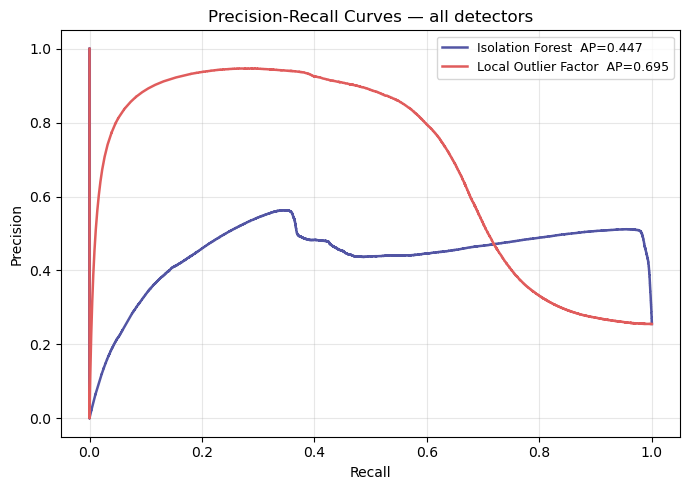

In [13]:
# Precision-Recall curves 
colours = ["#5255A4", "#E05C5C", "#3B9EBF"]

fig, ax = plt.subplots(figsize=(7, 5))
for res, col in zip(results, colours):
    p, r, _ = precision_recall_curve(y_te_seq, res["scores"])
    ax.plot(r, p, color=col, lw=1.8, label=f"{res['name']}  AP={res['ap']:.3f}")

ax.set(xlabel="Recall", ylabel="Precision",
       title="Precision-Recall Curves — all detectors")
ax.legend(fontsize=9);  ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

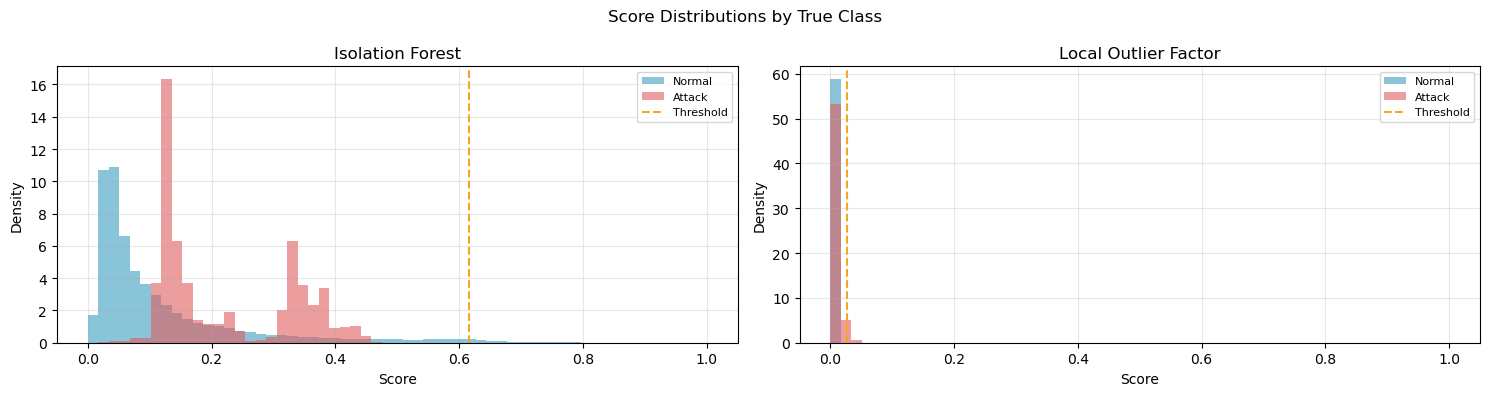

In [17]:
# Score distributions by true class 
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=False)

for ax, res in zip(axes, results):
    bins = np.linspace(res["scores"].min(), res["scores"].max(), 60)
    ax.hist(res["scores"][y_te_seq==0], bins=bins, alpha=0.6,
            color="#3B9EBF", label="Normal", density=True)
    ax.hist(res["scores"][y_te_seq==1], bins=bins, alpha=0.6,
            color="#E05C5C", label="Attack", density=True)
    ax.axvline(res["threshold"], color="#F5A623", ls="--", label="Threshold")
    ax.set(title=res["name"], xlabel="Score", ylabel="Density")
    ax.legend(fontsize=8);  ax.grid(alpha=0.3)

fig.suptitle("Score Distributions by True Class", fontsize=12)
fig.tight_layout()
plt.show()


In [16]:
# Summary table 
summary = pd.DataFrame([
    {"Detector": r["name"], "ROC-AUC": round(r["auc"], 4), "AUPRC": round(r["ap"], 4)}
    for r in results
]).set_index("Detector")

print("\n" + "="*45)
print(" FINAL RESULTS SUMMARY")
print("="*45)
print(summary.to_string())
print("="*45)



 FINAL RESULTS SUMMARY
                      ROC-AUC   AUPRC
Detector                             
Isolation Forest       0.8071  0.4470
Local Outlier Factor   0.7814  0.6948
